In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('housing.csv')
print(df.head())
print(df.info())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639

In [5]:
print(df.head())
print(df.info())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639

In [11]:
# Drop rows with missing values
df_clean = df.dropna()
print(f"Rows after cleaning: {len(df_clean)}")

Rows after cleaning: 20433


In [12]:
# Handle 'ocean_proximity' text column (encoding)
X = df_clean.copy()
X['ocean_proximity'] = X['ocean_proximity'].astype('category').cat.codes

# Separate features and target
X = X.drop('median_house_value', axis=1)
y = df_clean['median_house_value']

# Scale numeric features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature engineering complete!")
print(X_scaled.head())

Feature engineering complete!
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.327314  1.051717            0.982163    -0.803813       -0.970325   
1  -1.322323  1.042355           -0.606210     2.042130        1.348276   
2  -1.332305  1.037674            1.855769    -0.535189       -0.825561   
3  -1.337296  1.037674            1.855769    -0.623510       -0.718768   
4  -1.337296  1.037674            1.855769    -0.461970       -0.611974   

   population  households  median_income  ocean_proximity  
0   -0.973320   -0.976833       2.345163         1.291351  
1    0.861339    1.670373       2.332632         1.291351  
2   -0.819769   -0.843427       1.782939         1.291351  
3   -0.765056   -0.733562       0.932970         1.291351  
4   -0.758879   -0.628930      -0.013143         1.291351  


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (16346, 9)
Test set: (4087, 9)


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [15]:
score = model.score(X_test, y_test)
print(f"Model Accuracy (R²): {score:.4f}")

Model Accuracy (R²): 0.6399


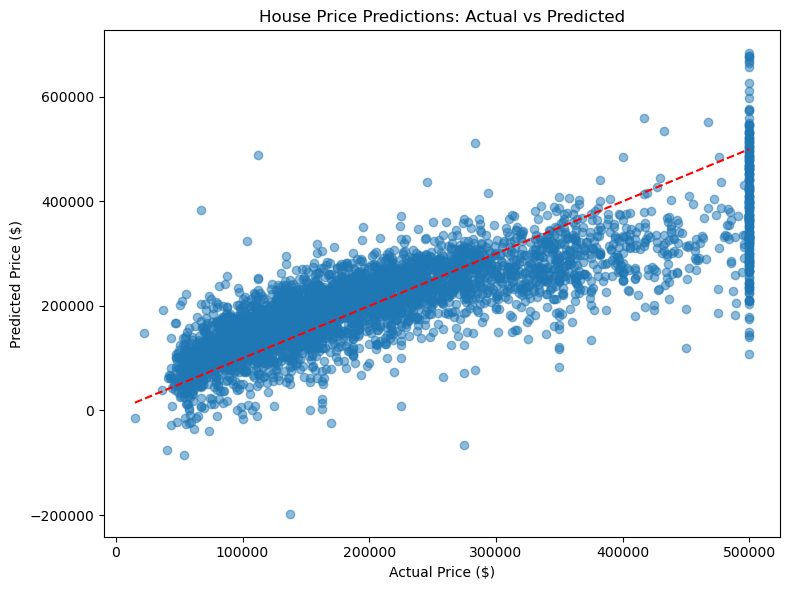

In [16]:
# Predicted vs Actual Prices Plot
y_pred = model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('House Price Predictions: Actual vs Predicted')
plt.tight_layout()
plt.show()

In [17]:
# Print summary for stakeholders
print("=" * 50)
print("PROJECT SUMMARY")
print("=" * 50)
print(f"Model: Linear Regression")
print(f"R² Score: {score:.4f}")
print(f"Training Samples: {len(X_train)}")
print(f"Test Samples: {len(X_test)}")
print("=" * 50)
print("LIMITATIONS:")
print("- Linear model assumes simple relationships")
print("- No geographic feature engineering yet")
print("- Single data source only")
print("=" * 50)
print("FUTURE IMPROVEMENTS:")
print("- Try Random Forest or Gradient Boosting")
print("- Add binning for age/income features")
print("- Include external data (schools, crime, etc.)")
print("=" * 50)

PROJECT SUMMARY
Model: Linear Regression
R² Score: 0.6399
Training Samples: 16346
Test Samples: 4087
LIMITATIONS:
- Linear model assumes simple relationships
- No geographic feature engineering yet
- Single data source only
FUTURE IMPROVEMENTS:
- Try Random Forest or Gradient Boosting
- Add binning for age/income features
- Include external data (schools, crime, etc.)
